In [1]:
import torch
from orbitflows.dynamics import H, MWPotential2014_1D
from orbitflows.util import max_error_along_orbs, mean_error_along_orbs

import matplotlib.pyplot as plt

plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['font.size'] = 14
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['xtick.labelsize'] = 18 
plt.rcParams['ytick.labelsize'] = 18
plt.rcParams['xtick.major.width'] = 1.5
plt.rcParams['ytick.major.width'] = 1.5
plt.rcParams['ytick.right'] = True
plt.rcParams['xtick.top'] = True
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'STIXGeneral'
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['ytick.minor.visible'] = True

In [3]:
aa_z_angle_grid = torch.load('z_angle_grid/mw_aa_z_angle_grid.pt')
ps_z_angle_grid = torch.load('z_angle_grid/mw_ps_z_angle_grid.pt')
freqs_z_angle_grid = torch.load('z_angle_grid/mw_freqs_z_angle_grid.pt')

aa_J_angle_grid = torch.load('J_angle_grid/mw_aa_J_angle_grid.pt')
ps_J_angle_grid = torch.load('J_angle_grid/mw_ps_J_angle_grid.pt')
freqs_J_angle_grid = torch.load('J_angle_grid/mw_freqs_J_angle_grid.pt')

Text(0, 0.5, '$p$')

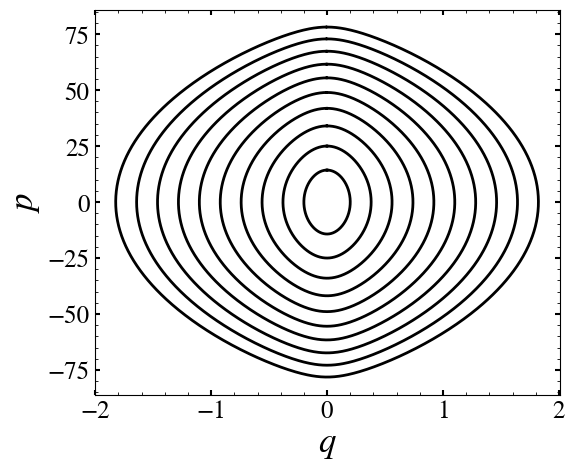

In [4]:
plt.figure(figsize=(6, 5))
plt.plot(ps_z_angle_grid[::50, ::5, 0].T*8, ps_z_angle_grid[::50, ::5,1].T*220, lw=2, zorder=5, c='k')
plt.xlabel('$q$', fontsize=25)
plt.ylabel('$p$', fontsize=25)

# Energy Conservation

<>:12: SyntaxWarning: invalid escape sequence '\l'

<>:12: SyntaxWarning: invalid escape sequence '\l'

/tmp/ipykernel_31746/476875831.py:12: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel('$ \log_{10}\\left (\\frac{\Delta E}{\langle E \\rangle} \\right )$', fontsize=25)



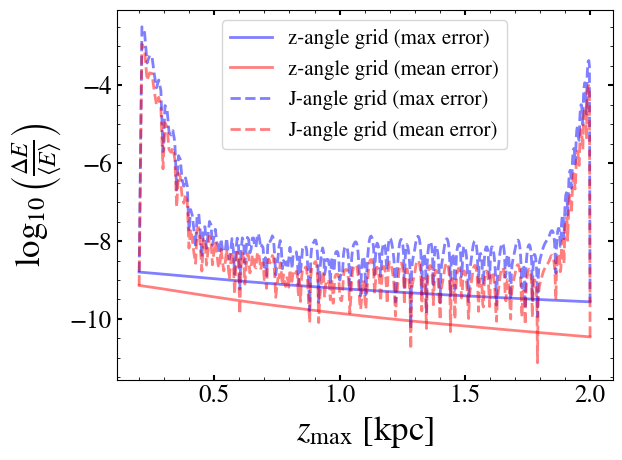

In [11]:
ro = 8
z_max_list_z_grid = torch.max(ps_z_angle_grid[...,0], dim=-1).values * ro
z_max_list_J_grid = torch.max(ps_J_angle_grid[...,0], dim=-1).values * ro

plt.plot(z_max_list_z_grid.detach(), max_error_along_orbs(H(ps_z_angle_grid, MWPotential2014_1D)).detach(), c='b', alpha=0.5, lw=2, label='z-angle grid (max error)')
plt.plot(z_max_list_z_grid.detach(), mean_error_along_orbs(H(ps_z_angle_grid, MWPotential2014_1D)).detach(),  c='r', alpha=0.5, lw=2, label='z-angle grid (mean error)')

plt.plot(z_max_list_J_grid.detach(), max_error_along_orbs(H(ps_J_angle_grid, MWPotential2014_1D)).detach(), c='b', alpha=0.5, lw=2, ls='--', label='J-angle grid (max error)')
plt.plot(z_max_list_J_grid.detach(), mean_error_along_orbs(H(ps_J_angle_grid, MWPotential2014_1D)).detach(),  c='r', alpha=0.5, lw=2, ls='--', label='J-angle grid (mean error)')

plt.xlabel('$z_{\\text{max}}$ [kpc]', fontsize=25)
plt.ylabel('$ \log_{10}\\left (\\frac{\Delta E}{\langle E \\rangle} \\right )$', fontsize=25)
plt.legend(fontsize=15)

# Action Conservation

<>:12: SyntaxWarning: invalid escape sequence '\l'

<>:12: SyntaxWarning: invalid escape sequence '\l'

/tmp/ipykernel_31746/743337615.py:12: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel('$ \log_{10}\\left (\\frac{\Delta J}{\langle J \\rangle} \\right )$', fontsize=25)

/tmp/ipykernel_31746/743337615.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=15)



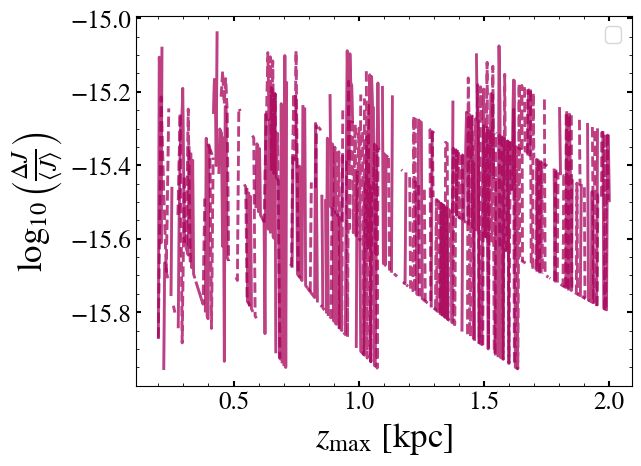

In [12]:
ro = 8
z_max_list_z_grid = torch.max(ps_z_angle_grid[...,0], dim=-1).values * ro
z_max_list_J_grid = torch.max(ps_J_angle_grid[...,0], dim=-1).values * ro

plt.plot(z_max_list_z_grid.detach(), max_error_along_orbs(aa_z_angle_grid[...,1]).detach(), c='b', alpha=0.5, lw=2)
plt.plot(z_max_list_z_grid.detach(), mean_error_along_orbs(aa_z_angle_grid[...,1]).detach(),  c='r', alpha=0.5, lw=2)

plt.plot(z_max_list_J_grid.detach(), max_error_along_orbs(aa_J_angle_grid[...,1]).detach(), c='b', alpha=0.5, lw=2, ls='--')
plt.plot(z_max_list_J_grid.detach(), mean_error_along_orbs(aa_J_angle_grid[...,1]).detach(),  c='r', alpha=0.5, lw=2, ls='--')

plt.xlabel('$z_{\\text{max}}$ [kpc]', fontsize=25)
plt.ylabel('$ \log_{10}\\left (\\frac{\Delta J}{\langle J \\rangle} \\right )$', fontsize=25)
plt.legend(fontsize=15)

# Frequencies

Text(0, 0.5, '$\\Omega$')

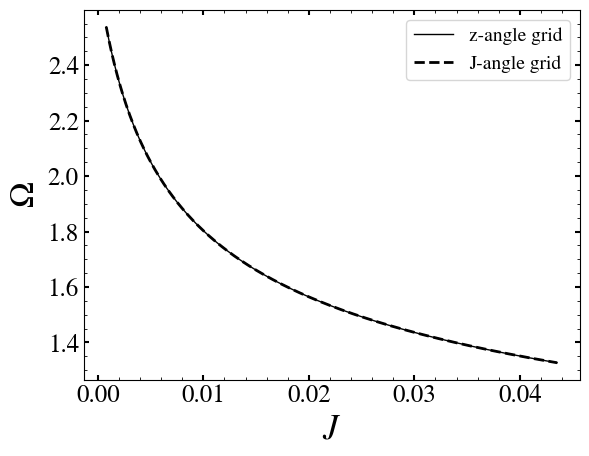

In [15]:
plt.plot(aa_z_angle_grid[:,0,1], freqs_z_angle_grid, c='k', ls='-', label='z-angle grid', lw=1)
plt.plot(aa_J_angle_grid[:,0,1], freqs_J_angle_grid, c='k', ls='--', label='J-angle grid', lw=2)
plt.legend()
plt.xlabel('$J$', fontsize=25)
plt.ylabel('$\\Omega$', fontsize=25)